In [1]:
import geopandas as gpd
import pandas as pd
pd.set_option('display.max_columns', None)

In [2]:
imd = gpd.read_file("input/dz18_pop23.zip")
imd.sort_values("population", inplace=True)
imd

,DZ2018,population,Shape_Leng,Shape_Area,geometry
6106,7602009.0,13.5000,4363.446486,8.203807e+05,"POLYGON ((1770808.791 5900000.24, 1770854.82 5..."
1676,3500038.0,122.2665,166619.214643,8.166741e+08,"POLYGON ((1754216.296 5636800.732, 1756649.63 ..."
2093,4400017.0,123.0000,7091.996430,1.804282e+06,"POLYGON ((1755989.702 5449222.408, 1755990.144..."
6105,7602008.0,171.0000,3922.254852,6.311570e+05,"POLYGON ((1771131.161 5900265.511, 1771135.165..."
5082,7600941.0,198.0000,496.422748,1.108125e+04,"POLYGON ((1756989.466 5920338.208, 1756973.025..."
...,...,...,...,...,...
3837,7000049.0,3419.4225,19784.938111,1.191750e+07,"POLYGON ((1263655.032 5002502.699, 1263761.223..."
6030,7601929.0,3724.8429,10562.903570,2.042429e+06,"POLYGON ((1748685.518 5947655.396, 1748684.769..."
6082,7601984.0,3962.6355,10523.843376,4.487524e+06,"POLYGON ((1773174.094 5906461.603, 1773253.116..."
6038,7601937.0,4084.7280,7090.724577,1.720748e+06,"POLYGON ((1748489.495 5926571.17, 1748544.608 ..."


In [3]:
dz = imd.iloc[0:1]
dz

,DZ2018,population,Shape_Leng,Shape_Area,geometry
6106,7602009.0,13.5,4363.446486,820380.70912,"POLYGON ((1770808.791 5900000.24, 1770854.82 5..."


In [4]:
neighbours = imd[imd.geometry.touches(dz.geometry.iloc[0])]
neighbours

,DZ2018,population,Shape_Leng,Shape_Area,geometry
6105,7602008.0,171.0000,3922.254852,631156.958440,"POLYGON ((1771131.161 5900265.511, 1771135.165..."
5863,7601748.0,585.0000,2902.681589,303823.906366,"POLYGON ((1770607.617 5899047.431, 1770608.265..."
5880,7601769.0,679.9176,2379.862614,180889.717302,"POLYGON ((1771127.371 5900627.388, 1771157.316..."
5832,7601715.0,705.8979,2181.656118,219727.796120,"POLYGON ((1770228.586 5898555.372, 1770101.192..."
5836,7601719.0,828.7881,1999.173897,162469.268237,"POLYGON ((1770424.433 5900281.972, 1770425.095..."
5803,7601685.0,981.0000,2376.325180,300020.695832,"POLYGON ((1769775.742 5899779.167, 1769764.991..."
5886,7601775.0,1749.0000,1655.873022,158468.822464,"POLYGON ((1770939.441 5898700.22, 1770899.151 ..."
5806,7601689.0,2079.1329,5954.486438,995948.949146,"POLYGON ((1769887.741 5899851.885, 1769886.344..."


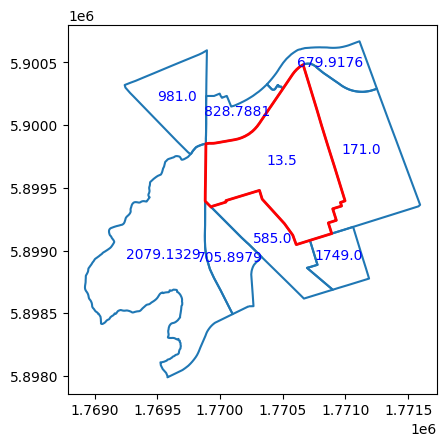

In [5]:
ax = neighbours.boundary.plot()
ax = dz.boundary.plot(ax=ax, color="red", linewidth=2)
p = dz.centroid.iloc[0]
ax.annotate(text=str(dz.population.iloc[0]), xy=[p.x, p.y], ha='center', color="blue")
for neighbour in neighbours.itertuples():
  p = neighbour.geometry.centroid
  ax.annotate(text=str(neighbour.population), xy=[p.x, p.y], ha='center', color="blue")

In [6]:
merged = pd.concat((dz, neighbours.iloc[0:1])).dissolve(aggfunc={
    "DZ2018": "first",
    "population": "sum",
})
merged.index = dz.index
merged

,geometry,DZ2018,population
6106,"POLYGON ((1770866.555 5899127.62, 1770717.138 ...",7602009.0,184.5


<Axes: >

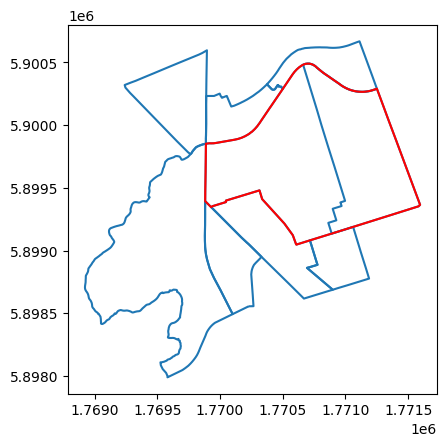

In [7]:
ax = neighbours.boundary.plot()
merged.boundary.plot(ax=ax, color="red")

In [8]:
while imd.population.iloc[0] < 399:
    dz = imd.iloc[0:1]
    neighbours = imd[imd.geometry.touches(dz.geometry.iloc[0])]
    merged = pd.concat((dz, neighbours.iloc[0:1])).dissolve(aggfunc={
        "DZ2018": "first",
        "population": "sum",
    })
    print(f"Merging {dz.DZ2018.iloc[0]} ({dz.population.iloc[0]}) with {neighbours.DZ2018.iloc[0]} ({neighbours.population.iloc[0]}) into {merged.DZ2018.iloc[0]} ({merged.population.iloc[0]})")
    merged.index = dz.index
    imd.drop(neighbours.index[0], inplace=True)
    imd.update(merged)
    imd.sort_values("population", inplace=True)
imd

Merging 7602009.0 (13.5) with 7602008.0 (171.0) into 7602009.0 (184.5)
Merging 3500038.0 (122.2665) with 3500035.0 (492.0) into 3500038.0 (614.2665)
Merging 4400017.0 (123.0) with 4400013.0 (425.25) into 4400017.0 (548.25)
Merging 7602009.0 (184.5) with 7601818.0 (450.0) into 7602009.0 (634.5)
Merging 7600941.0 (198.0) with 7600939.0 (426.1488) into 7600941.0 (624.1487999999999)
Merging 4400001.0 (213.75) with 4400005.0 (520.9062) into 4400001.0 (734.6562)
Merging 200067.0 (236.9997) with 200122.0 (431.4) into 200067.0 (668.3996999999999)
Merging 4500022.0 (251.8113) with 4500024.0 (835.257) into 4500022.0 (1087.0683)
Merging 2400084.0 (257.9781) with 2400086.0 (569.3784) into 2400084.0 (827.3565000000001)
Merging 200030.0 (285.0) with 200023.0 (499.0056) into 200030.0 (784.0056)
Merging 2100047.0 (295.002) with 2100048.0 (368.1972) into 2100047.0 (663.1992)
Merging 7600407.0 (295.5) with 7600545.0 (610.2915) into 7600407.0 (905.7915)
Merging 7600079.0 (296.0037) with 7600102.0 (577.87

,DZ2018,population,Shape_Leng,Shape_Area,geometry
6095,7601998.0,410.1000,48703.573482,1.145582e+07,"POLYGON ((1762182.341 5906213.642, 1762229.325..."
1170,2500006.0,411.0000,153074.656383,9.723200e+08,"POLYGON ((1930353.319 5775340.337, 1931609.011..."
5846,7601729.0,416.0625,2925.875495,3.967733e+05,"POLYGON ((1770478.955 5910433.073, 1770444.51 ..."
5361,7601230.0,417.0000,1872.653158,1.493650e+05,"POLYGON ((1761988.772 5906284.836, 1761959.856..."
4192,7600024.0,425.5062,33619.210439,2.152926e+07,"MULTIPOLYGON (((1728270.693 5916357.479, 17282..."
...,...,...,...,...,...
3837,7000049.0,3419.4225,19784.938111,1.191750e+07,"POLYGON ((1263655.032 5002502.699, 1263761.223..."
6030,7601929.0,3724.8429,10562.903570,2.042429e+06,"POLYGON ((1748685.518 5947655.396, 1748684.769..."
6082,7601984.0,3962.6355,10523.843376,4.487524e+06,"POLYGON ((1773174.094 5906461.603, 1773253.116..."
6038,7601937.0,4084.7280,7090.724577,1.720748e+06,"POLYGON ((1748489.495 5926571.17, 1748544.608 ..."


In [9]:
imd.Shape_Leng = imd.geometry.length
imd.Shape_Area = imd.geometry.area

In [10]:
imd.to_file("output/IMD2018_merged_small_DZ.shp")

/usr/local/lib/python3.10/dist-packages/pyogrio/raw.py:709: RuntimeWarning: Value 972320008.883523107 of field Shape_Area of feature 1 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
/usr/local/lib/python3.10/dist-packages/pyogrio/raw.py:709: RuntimeWarning: Value 187590747.660901546 of field Shape_Area of feature 10 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
/usr/local/lib/python3.10/dist-packages/pyogrio/raw.py:709: RuntimeWarning: Value 503118371.003573239 of field Shape_Area of feature 20 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
/usr/local/lib/python3.10/dist-packages/pyogrio/raw.py:709: RuntimeWarning: Value 230487563.390095949 of field Shape_Area of feature 22 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
/usr/local/lib/python3.10/dist-packages/pyogrio/raw.p